In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

path = '/content/drive/MyDrive/MSML_Muhammad Ausid Addari'
os.chdir(path)

print("Direktori kerja saat ini:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Direktori kerja saat ini: /content/drive/MyDrive/MSML_Muhammad Ausid Addari


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah Heart Disease Dataset (heart.csv) yang berisi informasi medis pasien untuk memprediksi adanya risiko penyakit jantung (klasifikasi biner).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

--- Cek Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca      

/tmp/ipykernel_27114/1962848311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


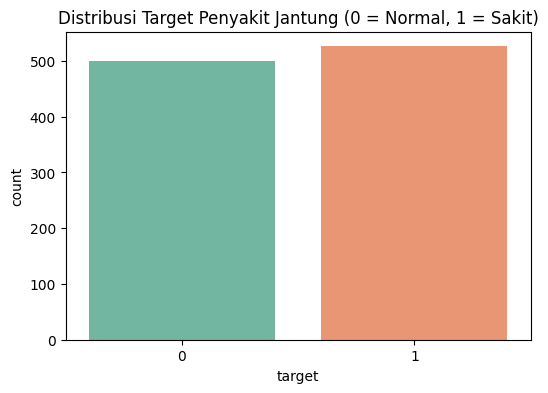

In [5]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Cek Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Target Penyakit Jantung (0 = Normal, 1 = Sakit)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
%%writefile heart_preprocessing.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_data(file_path: str) -> pd.DataFrame:
    """Memuat dataset dari file CSV."""
    df = pd.read_csv(file_path)
    return df

def preprocess_data(df: pd.DataFrame, target_column: str = 'target'):
    """
    Melakukan pembersihan data, penanganan duplikat,
    pemisahan fitur & label, serta scaling data.
    """

    df = df.drop_duplicates()

    df = df.dropna()

    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

Overwriting heart_preprocessing.py


In [7]:
from heart_preprocessing import load_data, preprocess_data

X_train, X_test, y_train, y_test, scaler = preprocess_data(df, target_column='target')

print(f"Preprocessing Selesai!")
print(f"Ukuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji  : {X_test.shape}")

Preprocessing Selesai!
Ukuran Data Latih: (241, 13)
Ukuran Data Uji  : (61, 13)


In [8]:
%%writefile DagsHub.txt
https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease

Overwriting DagsHub.txt


In [9]:
%%writefile Eksperimen_SML_Muhammad_Ausid_Addari.txt
https://colab.research.google.com/drive/https://drive.google.com/file/d/1T-mKWn_SzAIjyW9i-Ybuwoej1bXsn26t/view?usp=sharing

Overwriting Eksperimen_SML_Muhammad_Ausid_Addari.txt


In [10]:
# Install DVC & MLflow
!pip install dvc dagshub mlflow

# Set konfigurasi Git
!git config --global user.name "MuhammadAusid"
!git config --global user.email "ausidaddari123@gmail.com"

# Inisialisasi Git & DVC
!git init
!dvc init

# Tracking file dataset
!dvc add heart.csv
!git add heart.csv.dvc .gitignore
!git commit -m "Initial commit - tracking raw dataset with DVC"

Reinitialized existing Git repository in /content/drive/MyDrive/MSML_Muhammad Ausid Addari/.git/
ERROR: failed to initiate DVC - '.dvc' exists. Use `-f` to force.
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00,  5.58file/s{'info': ''}]

To track the changes with git, run:

	git add heart.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Membangun_model/modelling.py
	modified:   Membangun_model/modelling_tuning.py
	modified:   Membangun_model/r

In [11]:
# Login DagsHub CLI
!pip install dagshub

import dagshub

dagshub.init(
    repo_owner="MuhammadAusid",
    repo_name="SMSML-Heart-Disease",
    mlflow=True
)

Accessing as MuhammadAusid

Initialized MLflow to track repo "MuhammadAusid/SMSML-Heart-Disease"

Repository MuhammadAusid/SMSML-Heart-Disease initialized!

In [12]:
import os

# Membuat folder Membangun_model
os.makedirs("Membangun_model", exist_ok=True)
print("Folder Membangun_model berhasil dibuat!")

Folder Membangun_model berhasil dibuat!


In [13]:
import dagshub
import mlflow

# Inisialisasi koneksi MLflow ke DagsHub
dagshub.init(repo_owner='MuhammadAusid', repo_name='SMSML-Heart-Disease', mlflow=True)

# Cek URI Tracking MLflow
print("MLflow Tracking URI:", mlflow.get_tracking_uri())

Initialized MLflow to track repo "MuhammadAusid/SMSML-Heart-Disease"

Repository MuhammadAusid/SMSML-Heart-Disease initialized!

MLflow Tracking URI: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow


In [14]:
%%writefile Membangun_model/modelling.py

import os
import sys
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Import preprocessing
sys.path.append(
    os.path.abspath(
        os.path.join(
            os.path.dirname(__file__),
            ".."
        )
    )
)

from heart_preprocessing import load_data, preprocess_data


def train_baseline_model():


    data_path = os.path.abspath(
        os.path.join(
            os.path.dirname(__file__),
            "../heart.csv"
        )
    )

    df = load_data(data_path)

    X_train, X_test, y_train, y_test, scaler = preprocess_data(
        df,
        target_column="target"
    )


    mlflow.set_experiment("Heart Disease Classification")

    mlflow.autolog()

    with mlflow.start_run(run_name="Baseline_RandomForest"):

        model = RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        )

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

        accuracy = accuracy_score(y_test, prediction)
        precision = precision_score(y_test, prediction)
        recall = recall_score(y_test, prediction)
        f1 = f1_score(y_test, prediction)

        print("=" * 50)
        print("Baseline Random Forest")
        print("=" * 50)

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print("=" * 50)
        print("Training selesai.")
        print("=" * 50)


if __name__ == "__main__":
    train_baseline_model()

Overwriting Membangun_model/modelling.py


In [15]:
%%writefile Membangun_model/modelling_tuning.py

import os
import sys
import joblib
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sys.path.append(
    os.path.abspath(
        os.path.join(
            os.path.dirname(__file__),
            ".."
        )
    )
)

from heart_preprocessing import load_data, preprocess_data


def train_tuned_model():

    data_path = os.path.abspath(
        os.path.join(
            os.path.dirname(__file__),
            "../heart.csv"
        )
    )

    df = load_data(data_path)

    X_train, X_test, y_train, y_test, scaler = preprocess_data(
        df,
        target_column="target"
    )

    mlflow.set_experiment("Heart Disease Classification")
    mlflow.autolog()

    param_grid = {
        "n_estimators": [50, 100, 150],
        "max_depth": [3, 5, 10],
        "criterion": ["gini", "entropy"]
    }

    with mlflow.start_run(run_name="Tuned_RandomForest"):

        base_model = RandomForestClassifier(
            random_state=42
        )

        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_

        prediction = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, prediction)
        precision = precision_score(y_test, prediction)
        recall = recall_score(y_test, prediction)
        f1 = f1_score(y_test, prediction)

        print("=" * 50)
        print("Hyperparameter Tuning")
        print("=" * 50)

        print("Best Parameters")
        print(grid_search.best_params_)

        print()

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print("=" * 50)
        print("Training selesai.")
        print("=" * 50)

        model_dir = os.path.join(
            os.path.dirname(__file__),
            "saved_model"
        )

        os.makedirs(model_dir, exist_ok=True)

        joblib.dump(
            best_model,
            os.path.join(
                model_dir,
                "heart_model.pkl"
            )
        )

        print("Model berhasil disimpan pada:")
        print(os.path.join(model_dir, "heart_model.pkl"))


if __name__ == "__main__":
    train_tuned_model()

Overwriting Membangun_model/modelling_tuning.py


In [16]:
# Menjalankan training baseline
!python Membangun_model/modelling.py

print("=" * 70)

# Menjalankan training tuning
!python Membangun_model/modelling_tuning.py

2026/08/07 13:48:54 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/08/07 13:48:54 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/08/07 13:48:54 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2026/08/07 13:48:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Baseline Random Forest
Accuracy : 0.7705
Precision: 0.7879
Recall   : 0.7879
F1 Score : 0.7879
Training selesai.
🏃 View run Baseline_RandomForest at: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow/#/experiments/0/runs/4643624d7dd

In [17]:
%%writefile Membangun_model/requirements.txt
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.3.2
mlflow==2.11.3
dagshub==0.3.28
fastapi==0.110.0
uvicorn==0.28.0
prometheus-client==0.20.0
joblib==1.4.2

Overwriting Membangun_model/requirements.txt


In [18]:
%%writefile Membangun_model/MLproject
name: Heart_Disease_Classification

conda_env: conda.yaml

entry_points:

  baseline:
    command: "python modelling.py"

  tuning:
    command: "python modelling_tuning.py"

  train_all:
    command: |
      python modelling.py
      python modelling_tuning.py

Overwriting Membangun_model/MLproject


In [19]:
%%writefile Membangun_model/conda.yaml

name: heart-disease-mlops

channels:
  - conda-forge

dependencies:
  - python=3.11

  - pip

  - pip:
      - pandas==2.2.2
      - numpy==1.26.4
      - scikit-learn==1.3.2
      - mlflow==2.11.3
      - dagshub==0.3.28
      - fastapi==0.110.0
      - uvicorn==0.28.0
      - prometheus-client==0.20.0

Overwriting Membangun_model/conda.yaml


In [20]:
import os

os.makedirs(".github/workflows", exist_ok=True)

print("Folder .github/workflows berhasil dibuat.")

Folder .github/workflows berhasil dibuat.


In [21]:
%%writefile .github/workflows/ci.yml
name: Heart Disease MLOps CI

on:
  push:
    branches:
      - main

  pull_request:
    branches:
      - main

jobs:
  mlflow-project:
    runs-on: ubuntu-latest

    defaults:
      run:
        working-directory: Membangun_model

    steps:
      - name: Checkout Repository
        uses: actions/checkout@v4

      - name: Setup Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install Python Packages
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Install MLflow
        run: |
          pip install mlflow

      - name: Check Project Structure
        run: |
          pwd
          ls -R

      - name: Run MLflow Project
        run: |
          mlflow run . -e train_all

Overwriting .github/workflows/ci.yml


In [22]:
!cat .github/workflows/ci.yml

name: Heart Disease MLOps CI

on:
  push:
    branches:
      - main

  pull_request:
    branches:
      - main

jobs:
  mlflow-project:
    runs-on: ubuntu-latest

    defaults:
      run:
        working-directory: Membangun_model

    steps:
      - name: Checkout Repository
        uses: actions/checkout@v4

      - name: Setup Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install Python Packages
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Install MLflow
        run: |
          pip install mlflow

      - name: Check Project Structure
        run: |
          pwd
          ls -R

      - name: Run MLflow Project
        run: |
          mlflow run . -e train_all


In [23]:
%%writefile pre-processing.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def clean_and_preprocess_data(file_path: str):
    # Load dataset
    df = pd.read_csv(file_path)

    # Preprocessing
    df = df.drop_duplicates()
    df = df.dropna()

    X = df.drop(columns=['target'])
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

Overwriting pre-processing.py


In [24]:
import importlib

# Mengimpor modul pre-processing.py
pre_processing = importlib.import_module("pre-processing")
importlib.reload(pre_processing)

# Menjalankan fungsi preprocessing
X_train, X_test, y_train, y_test = pre_processing.clean_and_preprocess_data('heart.csv')

print("Pipeline Preprocessing Berhasil Dijalankan!")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")

Pipeline Preprocessing Berhasil Dijalankan!
Bentuk X_train: (241, 13)
Bentuk X_test : (61, 13)


In [25]:
%%writefile dvc.yaml
stages:
  preprocess:
    cmd: python pre-processing.py
    deps:
    - heart.csv
    - pre-processing.py

Overwriting dvc.yaml


In [26]:
# Lakukan reproduksi pipeline DVC
!dvc repro

# Simpan perubahan pipeline ke Git
!git add dvc.yaml dvc.lock
!git commit -m "Add DVC data preprocessing pipeline"

'heart.csv.dvc' didn't change, skipping
Stage 'preprocess' didn't change, skipping
Data and pipelines are up to date.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Membangun_model/modelling.py
	modified:   Membangun_model/modelling_tuning.py
	modified:   Membangun_model/requirements.txt
	deleted:    Monitoring dan Logging/7.Inference.py
	modified:   Template_Eksperimen_MSML.ipynb
	modified:   __pycache__/heart_preprocessing.cpython-312.pyc
	modified:   __pycache__/pre-processing.cpython-312.pyc
	modified:   pre-processing.py
	modified:   preprocessing.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.github/
	DagsHub.txt
	Membangun_model/MLproject
	Membangun_model/__pycache__/
	Membangun_model/conda.yaml
	Membangun_model/saved_model/
	Monitoring dan Log

In [27]:
import shutil

# Menyalin notebook saat ini menjadi preprocessing.ipynb
shutil.copy("Template_Eksperimen_MSML.ipynb", "preprocessing.ipynb")
print("File preprocessing.ipynb berhasil dibuat!")

File preprocessing.ipynb berhasil dibuat!


In [28]:
%%writefile Workflow-CI.txt
https://github.com/MuhammadAusid/SMSML-Heart-Disease/actions

Overwriting Workflow-CI.txt


In [29]:
import os

# Membuat folder utama dan subfolder bukti screenshot
base_dir = "Monitoring dan Logging"
os.makedirs(f"{base_dir}/4.bukti monitoring Prometheus", exist_ok=True)
os.makedirs(f"{base_dir}/5.bukti monitoring Grafana", exist_ok=True)
os.makedirs(f"{base_dir}/6.bukti alerting Grafana", exist_ok=True)

print("Struktur folder 'Monitoring dan Logging' berhasil dibuat!")

Struktur folder 'Monitoring dan Logging' berhasil dibuat!


In [30]:
%%writefile "Monitoring dan Logging/2.prometheus.yml"
global:
  scrape_interval: 15s

scrape_configs:
  - job_name: 'ml_model_exporter'
    static_configs:
      - targets: ['localhost:8000']

Overwriting Monitoring dan Logging/2.prometheus.yml


In [31]:
%%writefile "Monitoring dan Logging/3.prometheus_exporter.py"
import time
import random
from prometheus_client import start_http_server, Counter, Histogram

# Metrik Prometheus
PREDICTION_COUNTER = Counter('model_predictions_total', 'Total prediksi yang dilakukan')
LATENCY_HISTOGRAM = Histogram('model_prediction_latency_seconds', 'Waktu latensi prediksi')

def process_request():
    start_time = time.time()
    # Simulasi pemrosesan inferensi model
    time.sleep(random.uniform(0.1, 0.5))
    PREDICTION_COUNTER.inc()
    LATENCY_HISTOGRAM.observe(time.time() - start_time)

if __name__ == '__main__':
    # Jalankan server Prometheus Exporter di port 8000
    start_http_server(8000)
    print("Prometheus exporter berjalan di http://localhost:8000")
    while True:
        process_request()
        time.sleep(1)

Overwriting Monitoring dan Logging/3.prometheus_exporter.py


In [32]:
%%writefile "Monitoring dan Logging/inference.py"

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import os

app = FastAPI(
    title="Heart Disease Prediction API",
    description="API untuk prediksi penyakit jantung menggunakan Random Forest",
    version="1.0.0"
)

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

MODEL_PATH = os.path.abspath(
    os.path.join(
        BASE_DIR,
        "..",
        "Membangun_model",
        "saved_model",
        "heart_model.pkl"
    )
)

print("Model Path :", MODEL_PATH)
print("Model Exists :", os.path.exists(MODEL_PATH))

model = joblib.load(MODEL_PATH)


class HeartData(BaseModel):
    age: float
    sex: float
    cp: float
    trestbps: float
    chol: float
    fbs: float
    restecg: float
    thalach: float
    exang: float
    oldpeak: float
    slope: float
    ca: float
    thal: float


@app.get("/")
def home():
    return {
        "message": "Heart Disease Prediction API is running"
    }


@app.post("/predict")
def predict(data: HeartData):

    df = pd.DataFrame([data.dict()])

    prediction = int(model.predict(df)[0])

    return {
        "prediction": prediction
    }

Overwriting Monitoring dan Logging/inference.py


In [33]:
import os

old_name = "Monitoring dan Logging/7.Inference.py"
new_name = "Monitoring dan Logging/inference.py"

if os.path.exists(old_name):
    os.rename(old_name, new_name)
    print("Berhasil diubah menjadi inference.py")
else:
    print("File sudah bernama inference.py atau tidak ditemukan.")

File sudah bernama inference.py atau tidak ditemukan.


In [43]:
!uvicorn "Monitoring dan Logging.inference:app" --host 0.0.0.0 --port 8000

Model Path : /content/drive/MyDrive/MSML_Muhammad Ausid Addari/Membangun_model/saved_model/heart_model.pkl
Model Exists : True
INFO:     Started server process [32669]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Finished server process [32669]
^C


In [39]:
import requests

response = requests.get("http://127.0.0.1:8000")
print(response.status_code)
print(response.json())

200
{'message': 'Heart Disease Prediction API is running'}


In [40]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "age": 52,
    "sex": 1,
    "cp": 0,
    "trestbps": 125,
    "chol": 212,
    "fbs": 0,
    "restecg": 1,
    "thalach": 168,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 2,
    "thal": 3
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'prediction': 1}


In [41]:
!pkill -f uvicorn

In [42]:
!ps -ef | grep uvicorn

root       31730   27114  0 14:01 ?        00:00:00 /bin/bash -c ps -ef | grep uvicorn
root       31732   31730  0 14:01 ?        00:00:00 grep uvicorn


In [47]:
%%bash
git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Membangun_model/modelling.py
	modified:   Membangun_model/modelling_tuning.py
	modified:   Membangun_model/requirements.txt
	modified:   Monitoring dan Logging/1.bukti_serving.jpg
	deleted:    Monitoring dan Logging/7.Inference.py
	modified:   Template_Eksperimen_MSML.ipynb
	deleted:    __pycache__/heart_preprocessing.cpython-312.pyc
	deleted:    __pycache__/pre-processing.cpython-312.pyc
	modified:   pre-processing.py
	modified:   preprocessing.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.github/
	DagsHub.txt
	Membangun_model/MLproject
	Membangun_model/conda.yaml
	Membangun_model/saved_model/
	Monitoring dan Logging/inference.py
	heart_preprocessing.py

no changes added to commit (use "git add" and/or 

In [48]:
%%bash
rm -rf __pycache__
rm -rf Membangun_model/__pycache__
rm -rf "Monitoring dan Logging/__pycache__"
rm -f server.log

In [49]:
%%bash
git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Membangun_model/modelling.py
	modified:   Membangun_model/modelling_tuning.py
	modified:   Membangun_model/requirements.txt
	modified:   Monitoring dan Logging/1.bukti_serving.jpg
	deleted:    Monitoring dan Logging/7.Inference.py
	modified:   Template_Eksperimen_MSML.ipynb
	deleted:    __pycache__/heart_preprocessing.cpython-312.pyc
	deleted:    __pycache__/pre-processing.cpython-312.pyc
	modified:   pre-processing.py
	modified:   preprocessing.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.github/
	DagsHub.txt
	Membangun_model/MLproject
	Membangun_model/conda.yaml
	Membangun_model/saved_model/
	Monitoring dan Logging/inference.py
	heart_preprocessing.py

no changes added to commit (use "git add" and/or 

In [51]:
%%bash
git add .
git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .github/workflows/ci.yml
	new file:   DagsHub.txt
	new file:   Membangun_model/MLproject
	new file:   Membangun_model/conda.yaml
	modified:   Membangun_model/modelling.py
	modified:   Membangun_model/modelling_tuning.py
	modified:   Membangun_model/requirements.txt
	new file:   Membangun_model/saved_model/heart_model.pkl
	modified:   Monitoring dan Logging/1.bukti_serving.jpg
	deleted:    Monitoring dan Logging/7.Inference.py
	new file:   Monitoring dan Logging/inference.py
	modified:   Template_Eksperimen_MSML.ipynb
	deleted:    __pycache__/heart_preprocessing.cpython-312.pyc
	deleted:    __pycache__/pre-processing.cpython-312.pyc
	new file:   heart_preprocessing.py
	modified:   pre-processing.py
	modified:   preprocessing.ipynb



In [ ]:
%%bash
git add .
git commit -m "Update monitoring, inference API, MLflow project and CI workflow"
git push origin main